In [13]:
# import google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!ls -lh "/content/drive/MyDrive/project_214A"

total 457K
-rw------- 1 root root 150K Mar 13 01:08 'Advait baseline.ipynb'
drwx------ 2 root root 4.0K Mar  3 19:50 'audio recordings- spec pres'
drwx------ 2 root root 4.0K Mar 11 05:43  code
-rw------- 1 root root 143K Mar  5 04:23 "Farrah's baseline.ipynb"
-rw------- 1 root root  24K Mar 11 07:19 'Final Code.ipynb'
-rw------- 1 root root  15K Mar 11 05:13  final_code.py
-rw------- 1 root root 112K Mar  3 20:36  M214A_26_Winter_proj-3.pdf
drwx------ 7 root root 4.0K Feb 11 23:48  M214_project_data
-rw------- 1 root root  180 Mar 11 17:04 'Noise Robust Digit Recognition.gslides'
-rw------- 1 root root  180 Mar  9 17:55  Results.gdoc
-rw------- 1 root root  180 Mar  3 20:02 'Spectrogram Reading.gslides'


In [15]:
import os
from glob import glob

base = "/content/drive/MyDrive/project_214A"

print("Base exists?", os.path.exists(base))
if os.path.exists(base):
    print("Base contents:", os.listdir(base))

# Find wavs anywhere under that folder (recursive, case-insensitive)
wavs = glob(base + "/**/*.wav", recursive=True) + glob(base + "/**/*.WAV", recursive=True)
print("Num wav files found:", len(wavs))
print("First 10:", wavs[:10])

Base exists? True
Base contents: ['M214_project_data', 'audio recordings- spec pres', 'Spectrogram Reading.gslides', 'M214A_26_Winter_proj-3.pdf', "Farrah's baseline.ipynb", 'Results.gdoc', 'Advait baseline.ipynb', 'final_code.py', 'code', 'Final Code.ipynb', 'Noise Robust Digit Recognition.gslides']
Num wav files found: 3700
First 10: ['/content/drive/MyDrive/project_214A/M214_project_data/test_clean/8_jackson_3.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/3_nicolas_3.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/8_jackson_2.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/0_theo_4.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/5_jackson_2.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/9_george_3.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/0_lucas_4.wav', '/content/drive/MyDrive/project_214A/M214_project_data/test_clean/2_jackson_0.w

In [16]:
import os
import random
import numpy as np
import copy

# Set before CUDA ops for deterministic CUDA kernels.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchaudio
import librosa
from glob import glob

SEED = 0

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [17]:
# ============================================================
# Dataset paths
# ============================================================
TRAIN_DIR = "/content/drive/MyDrive/project_214A/M214_project_data/train_clean"
TEST_CLEAN_DIR = "/content/drive/MyDrive/project_214A/M214_project_data/test_clean"
TEST_NOISY_5DB_DIR = "/content/drive/MyDrive/project_214A/M214_project_data/test_snr_5db_babble"
TEST_NOISY_10DB_DIR = "/content/drive/MyDrive/project_214A/M214_project_data/test_snr_10db_babble"

# ============================================================
# Audio loading
# ============================================================

def load_audio(audio_file):
    audio, fs = torchaudio.load(audio_file)
    audio = audio.numpy().reshape(-1)
    return audio, int(fs)

In [18]:
# ============================================================
# Feature extraction — add new extractors here
# ============================================================
'''
def extract_feature(audio, fs):
    """Extract feature from raw audio. Returns 2-D array (F, T).

    Replace or extend this function to use different features.
    """
    N_MFCC = 13
    WIN_LENGTH = 200
    HOP_LENGTH = 80
    N_FFT = 256
    return librosa.feature.mfcc(y=audio, sr=fs, n_mfcc=N_MFCC,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)

def extract_feature_from_file(audio_file):
    audio, fs = load_audio(audio_file)
    return extract_feature(audio, fs)



import numpy as np
import librosa

def extract_feature(audio, fs):
    """Extract noise-robust features from raw audio. Returns 2-D array (F, T).

    Features:
      - 13 MFCC
      - per-utterance CMVN
      - delta + delta-delta
    Output shape: (39, T)
    """
    N_MFCC = 13
    WIN_LENGTH = 200      # 25 ms at 8 kHz
    HOP_LENGTH = 80       # 10 ms at 8 kHz (100 Hz frame rate)
    N_FFT = 256

    # 1) Static MFCCs: shape (13, T)
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=fs,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    )

    # 2) Per-utterance CMVN (mean + variance normalization over time axis)
    # axis=1? No: features are rows, time is columns => normalize each row over columns.
    eps = 1e-8
    mfcc_mean = np.mean(mfcc, axis=1, keepdims=True)
    mfcc_std = np.std(mfcc, axis=1, keepdims=True)
    mfcc_cmvn = (mfcc - mfcc_mean) / (mfcc_std + eps)

    # 3) Temporal derivatives (computed on normalized MFCCs)
    delta = librosa.feature.delta(mfcc_cmvn, order=1)
    delta2 = librosa.feature.delta(mfcc_cmvn, order=2)

    # 4) Concatenate along feature axis => (39, T)
    feat = np.vstack([mfcc_cmvn, delta, delta2])

    return feat

def extract_feature_from_file(audio_file):
    audio, fs = load_audio(audio_file)
    return extract_feature(audio, fs)



import numpy as np
import librosa

def _cmvn(feat, eps=1e-8):
    """Per-utterance CMVN over time axis. feat shape: (F, T)"""
    mu = np.mean(feat, axis=1, keepdims=True)
    sd = np.std(feat, axis=1, keepdims=True)
    return (feat - mu) / (sd + eps)

def _safe_delta(feat, order=1):
    """
    librosa delta requires odd width >= 3 and width <= number of frames.
    This helper avoids crashes on very short utterances.
    """
    T = feat.shape[1]
    if T < 3:
        return np.zeros_like(feat)

    # choose largest odd width <= min(9, T)
    width = min(9, T)
    if width % 2 == 0:
        width -= 1
    if width < 3:
        return np.zeros_like(feat)

    return librosa.feature.delta(feat, order=order, width=width)

def extract_feature(audio, fs):
    """
    Noise-robust fused features. Returns (F, T)

    Stream A: MFCC(13) + CMVN + delta + delta-delta   => 39 dims
    Stream B: PCEN Mel(40) + CMVN                     => 40 dims

    Total: 79 dims
    """
    # --- framing params (baseline-compatible for 8kHz spoken digits) ---
    WIN_LENGTH = 200      # 25 ms @ 8 kHz
    HOP_LENGTH = 80       # 10 ms @ 8 kHz
    N_FFT = 256
    EPS = 1e-8

    # --- basic waveform cleanup (safe, feature-side only) ---
    # remove DC / mean offset
    audio = np.asarray(audio, dtype=np.float32)
    if audio.size == 0:
        return np.zeros((79, 1), dtype=np.float32)

    audio = audio - np.mean(audio)

    # peak-normalize to reduce loudness variation (safe)
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak

    # optional pre-emphasis (often helps MFCC robustness a bit)
    audio = librosa.effects.preemphasis(audio, coef=0.97)

    # ============================================================
    # Stream A: MFCC + CMVN + deltas
    # ============================================================
    N_MFCC = 13
    mfcc = librosa.feature.mfcc(
        y=audio, sr=fs,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    )  # (13, T)

    mfcc = _cmvn(mfcc, eps=EPS)
    d1 = _safe_delta(mfcc, order=1)
    d2 = _safe_delta(mfcc, order=2)

    stream_mfcc = np.vstack([mfcc, d1, d2])  # (39, T)

    # ============================================================
    # Stream B: Mel + PCEN (noise-robust)
    # ============================================================
    N_MELS = 64
    mel = librosa.feature.melspectrogram(
        y=audio, sr=fs,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        power=1.0  # magnitude-like is common for PCEN
    )  # (40, T)

    # PCEN parameters are reasonably conservative defaults.
    # You can tune these later.
    pcen = librosa.pcen(
        mel * (2**31),   # scaling often helps numerical behavior in librosa PCEN
        sr=fs,
        hop_length=HOP_LENGTH,
        gain=0.98,
        bias=2.0,
        power=0.5,
        time_constant=0.4,
        eps=1e-6
    )  # (40, T)

    # CMVN on PCEN stream too (sometimes helps even though PCEN already normalizes)
    stream_pcen = _cmvn(pcen, eps=EPS)  # (40, T)

    # ============================================================
    # Fuse streams
    # ============================================================
    feat = np.vstack([stream_mfcc, stream_pcen]).astype(np.float32)  # (79, T)
    return feat

def extract_feature_from_file(audio_file):
    audio, fs = load_audio(audio_file)
    return extract_feature(audio, fs)
    '''
import numpy as np
import librosa

def _cmvn(feat, eps=1e-8):
    mu = np.mean(feat, axis=1, keepdims=True)
    sd = np.std(feat, axis=1, keepdims=True)
    return (feat - mu) / (sd + eps)

def _safe_delta(feat, order=1):
    T = feat.shape[1]
    if T < 3:
        return np.zeros_like(feat)
    width = min(9, T)
    if width % 2 == 0:
        width -= 1
    if width < 3:
        return np.zeros_like(feat)
    return librosa.feature.delta(feat, order=order, width=width)

def extract_feature(audio, fs):
    WIN_LENGTH = 200
    HOP_LENGTH = 80
    N_FFT = 256
    N_MELS = 64
    N_MFCC = 13

    audio = np.asarray(audio, dtype=np.float32)
    if audio.size == 0:
        return np.zeros((231, 1), dtype=np.float32)

    # trim to remove low-energy leading and trailing parts of the signal
    audio, _ = librosa.effects.trim(audio, top_db=40)
    if audio.size == 0:
        return np.zeros((231, 1), dtype=np.float32)


    # ---------- PCEN stream ----------
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=fs,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    pcen = librosa.pcen(
        mel * (2**31),
        sr=fs,
        hop_length=HOP_LENGTH,
        time_constant=0.4
    )
    pcen = pcen - pcen.mean(axis=1, keepdims=True) # normalize (64)
    pcen_d1 = _safe_delta(pcen, order=1) # first derivative (64)
    pcen_d2 = _safe_delta(pcen, order=2) # second derivative (64)
    pcen_feat = np.vstack([pcen, pcen_d1, pcen_d2])   # 192 dims (64+64+64)


    # ---------- MFCC stream ----------
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=fs,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS
    )
    mfcc = _cmvn(mfcc) # normalize with CMVN (13)
    mfcc_d1 = _safe_delta(mfcc, order=1) # first derivative (13)
    mfcc_d2 = _safe_delta(mfcc, order=2) # second derivative (13)
    mfcc_feat = np.vstack([mfcc, mfcc_d1, mfcc_d2])   # 39 dims (13+13+13)

    feat = np.vstack([pcen_feat, mfcc_feat])          # 231 dims (192+39)
    return feat.astype(np.float32)

def extract_feature_from_file(audio_file):
    audio, fs = load_audio(audio_file)
    return extract_feature(audio, fs)

In [19]:
# ============================================================
# Dataset & DataLoader
# ============================================================

class FeatureDataset(torch.utils.data.Dataset):
    def __init__(self, X_list, y):
        self.X = X_list          # list of (F, T) np arrays
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])  # (F, T)
        return x, int(self.y[idx]), x.shape[1]


def collate_pad(batch):
    xs, ys, lens = zip(*batch)
    B = len(xs)
    F = xs[0].shape[0]
    T_max = max(lens)
    xb = torch.zeros(B, 1, F, T_max, dtype=xs[0].dtype)
    for i, x in enumerate(xs):
        xb[i, 0, :, :x.shape[1]] = x
    return xb, torch.tensor(ys, dtype=torch.long), torch.tensor(lens, dtype=torch.long)

# ============================================================
# Data loading
# ============================================================

def get_label(file_name):
    base = os.path.splitext(os.path.basename(file_name))[0]
    return int(base.split("_")[0])


def load_dir(data_dir, desc="Loading"):
    files = sorted(glob(os.path.join(data_dir, "*.wav")))
    if not files:
        print(f"No wav files found in {data_dir}")
        return [], []
    feats, labels = [], []
    for wav in files:
        feats.append(extract_feature_from_file(wav))
        labels.append(get_label(wav))
    print(f"  {desc}: {len(feats)} files loaded")
    return feats, labels

In [20]:
# ============================================================
# LSTM model
# ============================================================

class SimpleLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True,
            dropout=0.2
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 10),
        )

    def forward(self, x, lengths):
        # x: (B,1,F,T) -> (B,T,F)
        x = x.squeeze(1).permute(0, 2, 1).contiguous()

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)  # (B, T_max, 256)

        # ---- mean pooling over valid frames (ignore padding) ----
        B, T_max, D = out.shape
        device = out.device

        # mask: (B, T_max), True for valid timesteps
        mask = torch.arange(T_max, device=device).unsqueeze(0) < lengths.unsqueeze(1)

        # expand mask to (B, T_max, D) and zero-out padding
        mask_f = mask.unsqueeze(-1).float()
        out_sum = (out * mask_f).sum(dim=1)                       # (B, D)
        denom = mask_f.sum(dim=1).clamp(min=1.0)                  # (B, 1)
        mean = out_sum / denom                                    # (B, D)

        return self.classifier(mean)

In [21]:
# ============================================================
# Evaluation
# ============================================================

import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np
import torch

@torch.no_grad()
def evaluate(model, loader, device, plot_cm=False, class_names=None, title=None, save_path=None,
             return_metrics=False):
    """
    Returns:
      - if return_metrics=False and plot_cm=False:
            acc
      - if return_metrics=True and plot_cm=False:
            {"acc": acc, "macro_f1": macro_f1, "cm": cm, "y_true": y_true, "y_pred": y_pred}
      - if plot_cm=True:
            same metrics dict, and also plots confusion matrix
    """
    model.eval()
    if loader is None:
        if return_metrics or plot_cm:
            return {
                "acc": 0.0,
                "macro_f1": 0.0,
                "cm": None,
                "y_true": np.array([], dtype=np.int64),
                "y_pred": np.array([], dtype=np.int64),
            }
        return 0.0

    all_preds = []
    all_labels = []

    correct, total = 0, 0
    for xb, yb, lengths in loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        logits = model(xb, lengths)
        preds = logits.argmax(dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(yb.detach().cpu().numpy())

    acc = correct / total if total > 0 else 0.0

    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=np.int64)
    y_true = np.concatenate(all_labels) if all_labels else np.array([], dtype=np.int64)

    labels = list(range(len(class_names))) if class_names is not None else None
    cm = metrics.confusion_matrix(y_true, y_pred, labels=labels)
    macro_f1 = metrics.f1_score(y_true, y_pred, average="macro", zero_division=0)

    if plot_cm:
        disp = metrics.ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names if class_names is not None else None
        )
        disp.plot(values_format="d")
        plt.title(title or "Confusion Matrix")
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150)
            plt.close()
        else:
            plt.show()

    if return_metrics or plot_cm:
        return {
            "acc": acc,
            "macro_f1": macro_f1,
            "cm": cm,
            "y_true": y_true,
            "y_pred": y_pred,
        }

    return acc

In [22]:
# Training
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 3e-4

In [23]:
import time
import torch

# ---------------- TIMING START ----------------
t0 = time.perf_counter()

# --- Load data ---
train_feat, train_label   = load_dir(TRAIN_DIR, desc="Train")
test_feat,  test_label    = load_dir(TEST_CLEAN_DIR, desc="Test clean")
noisy5_feat, noisy5_label = load_dir(TEST_NOISY_5DB_DIR, desc="Test noisy 5dB")
noisy10_feat, noisy10_label = load_dir(TEST_NOISY_10DB_DIR, desc="Test noisy 10dB")

feat_dim = train_feat[0].shape[0]
print(f"\nFeature dim: {feat_dim}")
print(f"Train: {len(train_feat)}  |  Test clean: {len(test_feat)}  "
      f"|  Test noisy 5dB: {len(noisy5_feat)}  |  Test noisy 10dB: {len(noisy10_feat)}")

for name, flist in [("Train", train_feat), ("Test clean", test_feat),
                    ("Noisy 5dB", noisy5_feat), ("Noisy 10dB", noisy10_feat)]:
    if flist:
        lengths = [f.shape[1] for f in flist]
        print(f"  {name:10s} frames: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}")

y_train   = np.array(train_label, dtype=np.int64)
y_test    = np.array(test_label,  dtype=np.int64)
y_noisy5  = np.array(noisy5_label, dtype=np.int64)
y_noisy10 = np.array(noisy10_label, dtype=np.int64)

# --- DataLoaders ---
loader_g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    FeatureDataset(train_feat, y_train),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pad, generator=loader_g,
)
test_loader = DataLoader(
    FeatureDataset(test_feat, y_test),
    batch_size=16, shuffle=False, collate_fn=collate_pad
)
noisy5_loader = None
if noisy5_feat:
    noisy5_loader = DataLoader(
        FeatureDataset(noisy5_feat, y_noisy5),
        batch_size=16, shuffle=False, collate_fn=collate_pad,
    )
noisy10_loader = None
if noisy10_feat:
    noisy10_loader = DataLoader(
        FeatureDataset(noisy10_feat, y_noisy10),
        batch_size=16, shuffle=False, collate_fn=collate_pad,
    )

# finish "load/features" timing (include dataloader construction)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t1 = time.perf_counter()
# ---------------- TIMING: LOAD/FEATURES END ----------------


# --- Training ---
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SimpleLSTM(input_size=feat_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=LR)

best_clean, best_clean_ep = 0.0, -1
best_5db,  best_5db_ep  = 0.0, -1
best_10db, best_10db_ep = 0.0, -1

"""
Save the checkpoint with the best 10 dB accuracy.
You may instead choose to save the model with the best clean or 5 dB accuracy,
but keep in mind that your final score depends on strong performance on all of the test sets, especially the noisy test set.
"""
saved_checkpoint = None

for epoch in range(1, NUM_EPOCHS + 1):
    net.train()
    total_loss = 0.0
    for xb, yb, lengths in train_loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        optimizer.zero_grad()
        loss = criterion(net(xb, lengths), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    clean_acc = evaluate(net, test_loader, device)
    acc_5db  = evaluate(net, noisy5_loader, device)
    acc_10db = evaluate(net, noisy10_loader, device)

    print(f"Epoch {epoch:02d}  loss={avg_loss:.4f}  "
          f"clean={clean_acc:.4f}  5dB={acc_5db:.4f}  10dB={acc_10db:.4f}")

    if clean_acc > best_clean:
        best_clean, best_clean_ep = clean_acc, epoch
    if acc_5db > best_5db:
        best_5db, best_5db_ep = acc_5db, epoch
    if acc_10db > best_10db:
        best_10db, best_10db_ep = acc_10db, epoch
        saved_checkpoint = copy.deepcopy(net.state_dict())  # save the best checkpoint

# finish "train" timing
if torch.cuda.is_available():
    torch.cuda.synchronize()
t2 = time.perf_counter()
# ---------------- TIMING: TRAIN END ----------------


# --- Final evaluation timing (optional but nice) ---
# If you want this to reflect "best checkpoint", load it:
if saved_checkpoint is not None:
    net.load_state_dict(saved_checkpoint)

clean_final = evaluate(net, test_loader, device)
acc5_final  = evaluate(net, noisy5_loader, device)
acc10_final = evaluate(net, noisy10_loader, device)

if torch.cuda.is_available():
    torch.cuda.synchronize()
t3 = time.perf_counter()
# ---------------- TIMING: EVAL END ----------------

print(f"\nTiming:")
print(f"Load/features: {t1 - t0:.1f}s")
print(f"Train:         {t2 - t1:.1f}s")
print(f"Eval:          {t3 - t2:.1f}s")
print(f"TOTAL:         {t3 - t0:.1f}s")

print(f"\nFinal (best-ckpt) accuracies:")
print(f"clean={clean_final:.4f}  5dB={acc5_final:.4f}  10dB={acc10_final:.4f}")


  Train: 2500 files loaded
  Test clean: 300 files loaded
  Test noisy 5dB: 300 files loaded
  Test noisy 10dB: 300 files loaded

Feature dim: 231
Train: 2500  |  Test clean: 300  |  Test noisy 5dB: 300  |  Test noisy 10dB: 300
  Train      frames: min=15, max=229, mean=43.4
  Test clean frames: min=15, max=115, mean=42.8
  Noisy 5dB  frames: min=15, max=115, mean=43.6
  Noisy 10dB frames: min=15, max=115, mean=43.6
Epoch 01  loss=2.1819  clean=0.5900  5dB=0.3733  10dB=0.4200
Epoch 02  loss=1.1700  clean=0.8733  5dB=0.5633  10dB=0.6433
Epoch 03  loss=0.5254  clean=0.9233  5dB=0.6333  10dB=0.7500
Epoch 04  loss=0.2975  clean=0.9567  5dB=0.6767  10dB=0.7533
Epoch 05  loss=0.1841  clean=0.9533  5dB=0.7067  10dB=0.8300
Epoch 06  loss=0.1405  clean=0.9600  5dB=0.6900  10dB=0.8200
Epoch 07  loss=0.1000  clean=0.9833  5dB=0.6900  10dB=0.7767
Epoch 08  loss=0.1006  clean=0.9800  5dB=0.7333  10dB=0.8300
Epoch 09  loss=0.0617  clean=0.9733  5dB=0.7567  10dB=0.8467
Epoch 10  loss=0.0588  clean=0.

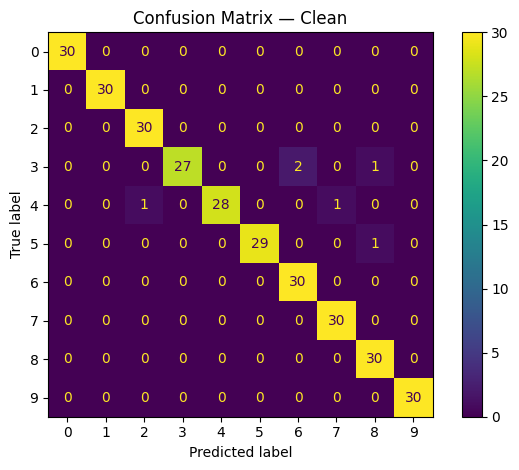

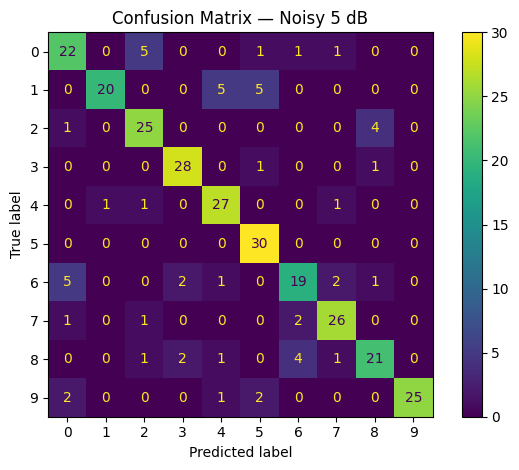

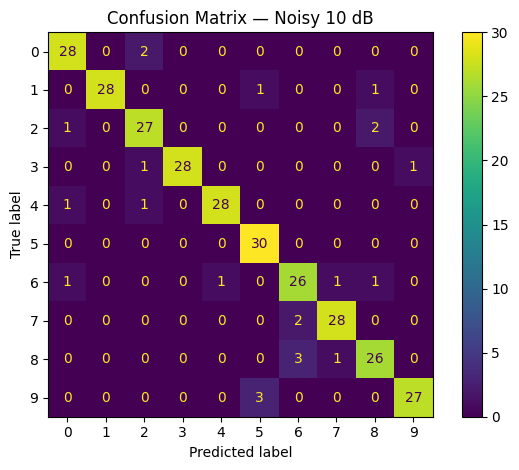


Best checkpoint loaded (epoch 35)

Final (best-ckpt) results:
Clean  : acc=0.9800  macro-F1=0.9799
5 dB   : acc=0.8100  macro-F1=0.8080
10 dB  : acc=0.9200  macro-F1=0.9204


In [24]:
# load the best checkpoint before testing
net = SimpleLSTM(input_size=feat_dim).to(device)
net.load_state_dict(saved_checkpoint)

metrics_clean = evaluate(
    net, test_loader, device,
    plot_cm=True,
    return_metrics=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Clean"
)

metrics_5db = evaluate(
    net, noisy5_loader, device,
    plot_cm=True,
    return_metrics=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Noisy 5 dB"
)

metrics_10db = evaluate(
    net, noisy10_loader, device,
    plot_cm=True,
    return_metrics=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Noisy 10 dB"
)

print(f"\nBest checkpoint loaded (epoch {best_10db_ep})")

print("\nFinal (best-ckpt) results:")
print(f"Clean  : acc={metrics_clean['acc']:.4f}  macro-F1={metrics_clean['macro_f1']:.4f}")
print(f"5 dB   : acc={metrics_5db['acc']:.4f}  macro-F1={metrics_5db['macro_f1']:.4f}")
print(f"10 dB  : acc={metrics_10db['acc']:.4f}  macro-F1={metrics_10db['macro_f1']:.4f}")